# Retail Data Wrangling and Analytics

In [1]:
# Import modules 
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Load Data from PSQL into DataFrame

**Setup Docker Containers**

![](https://i.imgur.com/VQrBVBk.jpg)

```
#make sure you have both Jupyter and PSQL docker container running
docker ps

#Attach a bridge network to both containers so they can communicate with each other
docker network create jarvis-net
#this command works on running containers
docker network connect jarvis-net jarvis-jupyter
docker network connect jarvis-net jarvis-psql

#verify both containers are attached to the jarvis-net
docker network inspect trading-net

#Note: instead of using `localhost`, you should use container names as hostnames.
```

**Data Preperation**

- Use [pandas.read_sql](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_sql.html) api to load the PSQL retail table into a Pandas DataFrame

![](https://i.imgur.com/AmkAP63.jpg)

- Get familair with the transaction date with `df.head()`, `df.sample(10)`, `df.info()`, `df.describe()`, etc..



In [2]:
#install psql "driver"
!pip3 install psycopg2-binary

     |████████████████████████████████| 3.0 MB 16.4 MB/s eta 0:00:01�███████                  | 1.3 MB 16.4 MB/s eta 0:00:01


In [3]:
import pandas as pd
from sqlalchemy import create_engine

# 1. Define the connection string (The address of your database)
# We use the IP 172.17.0.1 because your Jupyter and Postgres are in separate containers
db_host = '172.17.0.1'
db_user = 'postgres'
db_pass = 'password'
db_name = 'postgres'
db_port = '5432'

# 2. Create the engine
engine = create_engine(f'postgresql://{db_user}:{db_pass}@{db_host}:{db_port}/{db_name}')

# 3. Read the data from the 'retail' table
# We use 'read_sql' instead of 'read_sql_table' because it's more flexible
retail_df = pd.read_sql('SELECT * FROM retail', engine)

# 4. Show the first 5 rows to prove it worked
retail_df.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
retail_df.info()
retail_df.describe()

# Load CSV into Dataframe
Alternatively, the LGS IT team also dumped the transactional data into a [CSV file](https://raw.githubusercontent.com/jarviscanada/jarvis_data_eng_demo/feature/data/python_data_wrangling/data/online_retail_II.csv). However, the CSV header (column names) doesn't follow the snakecase or camelcase naming convention (e.g. `Customer ID` instead of `customer_id` or `CustomerID`). As a result, you will need to use Pandas to clean up the data before doing any analytics. In addition, unlike the PSQL scheme, CSV files do not have data types associated. Therefore, you will need to cast/convert certain columns into correct data types (e.g. DateTime, numbers, etc..)

**Data Preperation**

- Read the `data/online_retail_II.csv` file into a DataFrame
- Rename all columns to upper camelcase or snakecase
- Convert/cast all columns to the appropriate data types (e.g. datetime)

In [ ]:
retail_df = pd.read_csv
retail_df.head()

# Total Invoice Amount Distribution

---
**Please remove this insturction cell after you are done with coding**

1. Calculate the invoice amount. Note: an invoice consists of one or more items where each item is a row in the df. (hint: you need to `GROUP BY invoice`)
2. Draw the distribution of invoice amount with min, max, median, mod, and mean. However, you will notice many outlier data (e.g. invoices with large amounts). Sample hist and box charts:

![](https://i.imgur.com/N8hsbDa.jpg)

3. Draw the distribution for the first 85 quantiles of the invoice amount data with min, max, median, mod, and mean.


![](https://i.imgur.com/tJrH1qj.jpg)


---

Min: -168469.6
Max: 168469.6
Mean: 359.6488880435809
Median: 196.34499999999997


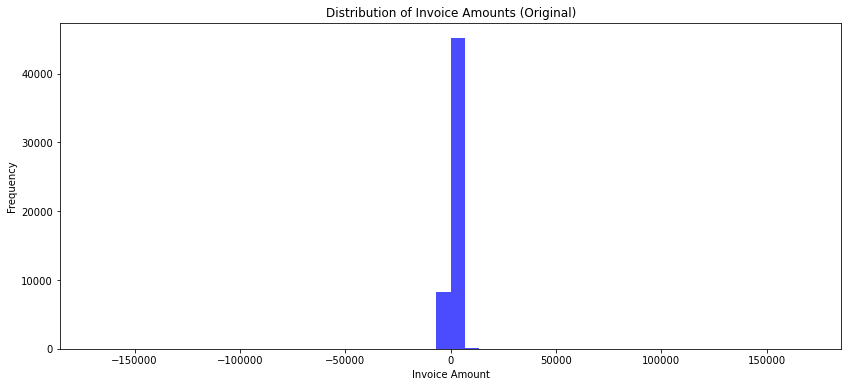

In [4]:
# 1. Calculate the line total 
retail_df['amount'] = retail_df['quantity'] * retail_df['unit_price']

# 2. Group by Invoice Number to get the total per invoice
invoice_amounts = retail_df.groupby('invoice_no')['amount'].sum()

# 3. Print the statistics
print("Min:", invoice_amounts.min())
print("Max:", invoice_amounts.max())
print("Mean:", invoice_amounts.mean())
print("Median:", invoice_amounts.median())

# 4. Plot the distribution (Histogram)
plt.figure(figsize=(14,6))
plt.hist(invoice_amounts, bins=50, color='blue', alpha=0.7)
plt.title('Distribution of Invoice Amounts (Original)')
plt.xlabel('Invoice Amount')
plt.ylabel('Frequency')
plt.show()


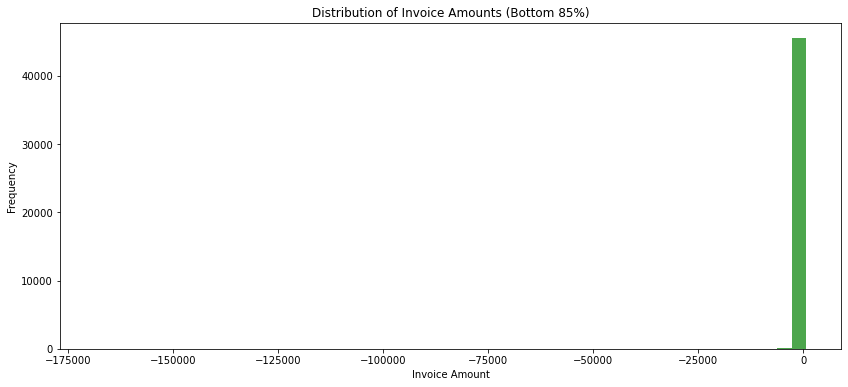

In [5]:
# 1. Find the value at the 85th percentile
limit_85 = invoice_amounts.quantile(0.85)

# 2. Filter the data to only keep invoices below that limit
invoice_amounts_85 = invoice_amounts[invoice_amounts <= limit_85]

# 3. Plot the filtered distribution
plt.figure(figsize=(14,6))
plt.hist(invoice_amounts_85, bins=50, color='green', alpha=0.7)
plt.title('Distribution of Invoice Amounts (Bottom 85%)')
plt.xlabel('Invoice Amount')
plt.ylabel('Frequency')
plt.show()

# Monthly Placed and Canceled Orders

---
**Please remove this insturction cell after you are done with coding**

- The attribute information (see the `project kick-off` section) contains useful information that helps you to identify canceled orders
- To simplify the problem, you can assume that there are two invoice numbers for each canceled order (one for the original invoice and one for the canceled invoice). Therefore, `# of placed orders = total # of orders - 2 * canceled order`. Furthermore, you can also assume the original invoice and canceled invoice are on always on the same day (this eliminate the case where the original invoice and canceled invoices are on different months)
- hints: you might want to create a new integer column with YYYYMM format. e.g. `2009-12-01 07:45:00 -> 200912` which allows easy GROUP BY.

**Sample Plot:**

![](https://i.imgur.com/tmLsPDf.jpg)

---

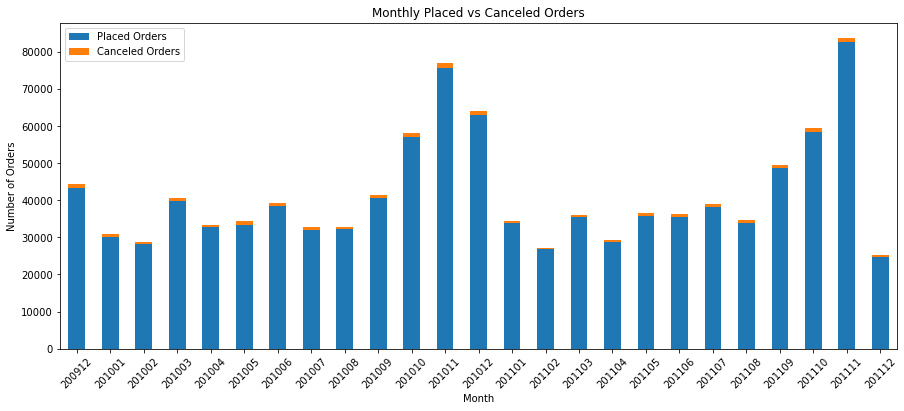

In [6]:
# 1. Convert the date column to a proper Datetime format (if not already)
retail_df['invoice_date'] = pd.to_datetime(retail_df['invoice_date'])

# 2. Create a YYYYMM column to make grouping by month easy
retail_df['yyyymm'] = retail_df['invoice_date'].dt.strftime('%Y%m')

# 3. Identify canceled orders (Invoice Numbers starting with 'C')
# We create a boolean series where True = Canceled
canceled_mask = retail_df['invoice_no'].str.startswith('C')

# 4. Group by Month (YYYYMM) to count totals
# Count total rows per month
total_orders = retail_df.groupby('yyyymm')['invoice_no'].count()
# Count only the canceled rows per month
canceled_orders = retail_df[canceled_mask].groupby('yyyymm')['invoice_no'].count()

# 5. Calculate "Placed" orders using the formula from the instructions:
# Placed = Total - (2 * Canceled)
# (Assumption: Each cancellation has a matching original order record)
placed_orders = total_orders - (2 * canceled_orders)

# 6. Create a DataFrame for plotting
orders_df = pd.DataFrame({
    'Placed Orders': placed_orders,
    'Canceled Orders': canceled_orders
})

# 7. Plot the chart
orders_df.plot(kind='bar', figsize=(15, 6), stacked=True, color=['#1f77b4', '#ff7f0e'])
plt.title('Monthly Placed vs Canceled Orders')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.legend()
plt.show()

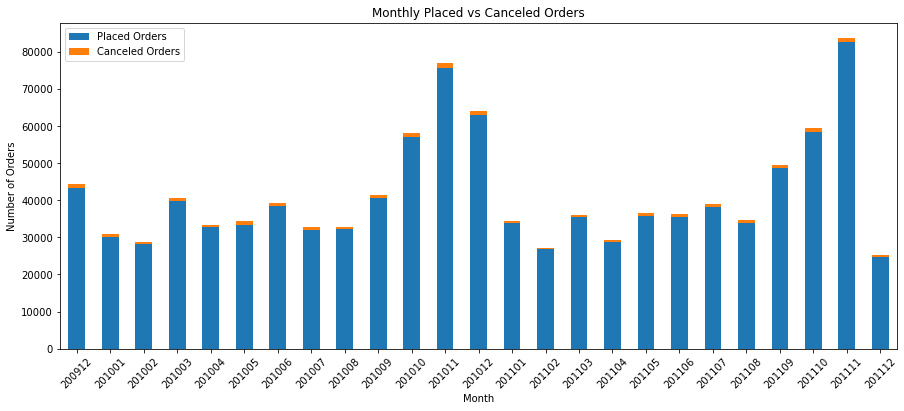

In [7]:
# 1. Convert the date column to a proper Datetime format 
retail_df['invoice_date'] = pd.to_datetime(retail_df['invoice_date'])

# 2. Create a YYYYMM column 
retail_df['yyyymm'] = retail_df['invoice_date'].dt.strftime('%Y%m')

# 3. Identify canceled orders (Invoice Numbers starting with 'C')
canceled_mask = retail_df['invoice_no'].str.startswith('C')

# 4. Group by Month (YYYYMM) to count totals
# Count total rows per month
total_orders = retail_df.groupby('yyyymm')['invoice_no'].count()
# Count only the canceled rows per month
canceled_orders = retail_df[canceled_mask].groupby('yyyymm')['invoice_no'].count()

# 5. Calculate "Placed" orders using the formula from the instructions:
placed_orders = total_orders - (2 * canceled_orders)

# 6. Create a DataFrame for plotting
orders_df = pd.DataFrame({
    'Placed Orders': placed_orders,
    'Canceled Orders': canceled_orders
})

# 7. Plot the chart
orders_df.plot(kind='bar', figsize=(15, 6), stacked=True, color=['#1f77b4', '#ff7f0e'])
plt.title('Monthly Placed vs Canceled Orders')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.legend()
plt.show()

# Monthly Sales

---
**Please remove this insturction cell after you are done with coding**


- Calculate the monthly sales data
- Plot a chart to show monthly sales (e.g. x-asix=year_month, y-axis=sales_amount)

![](https://i.imgur.com/k1KOqKO.jpg)

---

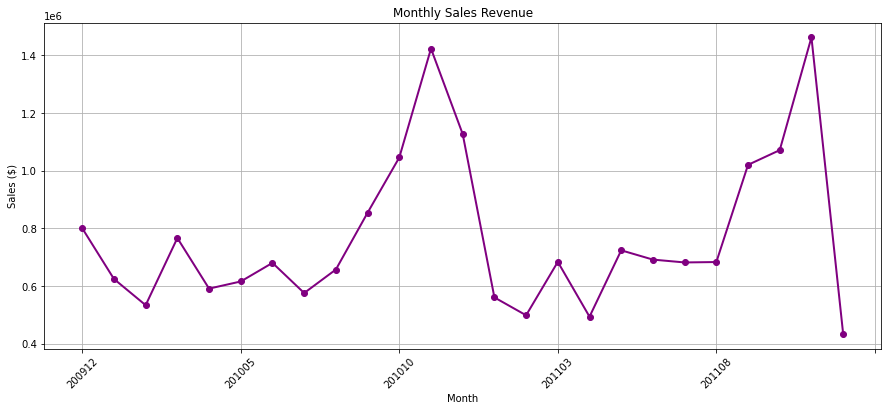

In [8]:
# Group by YYYYMM and sum the 'amount' column
monthly_sales = retail_df.groupby('yyyymm')['amount'].sum()

# Plot the line chart
plt.figure(figsize=(15,6))
monthly_sales.plot(kind='line', marker='o', color='purple', linewidth=2)

plt.title('Monthly Sales Revenue')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

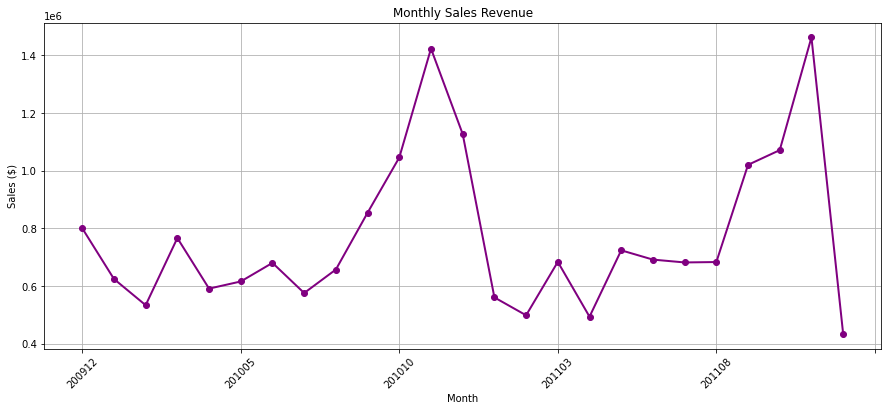

In [9]:
# Group by YYYYMM and sum the 'amount' column
monthly_sales = retail_df.groupby('yyyymm')['amount'].sum()

# Plot the line chart
plt.figure(figsize=(15,6))
monthly_sales.plot(kind='line', marker='o', color='purple', linewidth=2)

plt.title('Monthly Sales Revenue')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

# Monthly Sales Growth


---
**Please remove this insturction cell after you are done with coding**

- Calculate monthly sales percentage growth data
- Plot a chart to show the growth percentage

![](https://i.imgur.com/J3btp8j.jpg)

---

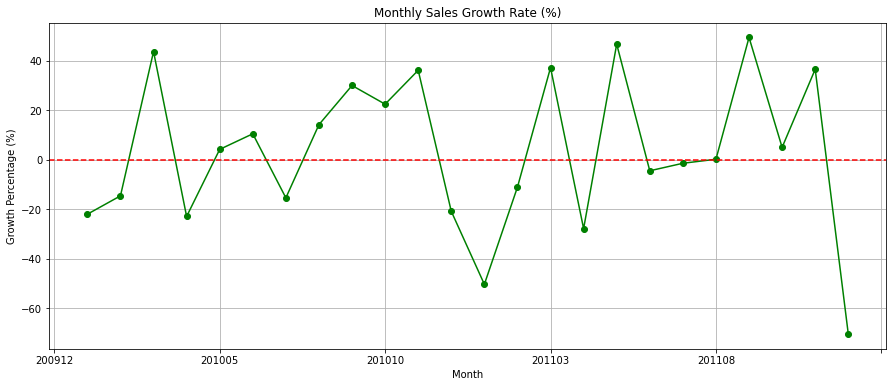

In [10]:
# Calculate monthly sales percentage growth
monthly_growth = monthly_sales.pct_change() * 100

# Plot the data
plt.figure(figsize=(15,6))
monthly_growth.plot(kind='line', marker='o', color='green')

plt.title('Monthly Sales Growth Rate (%)')
plt.xlabel('Month')
plt.ylabel('Growth Percentage (%)')
plt.grid(True)
plt.axhline(0, color='red', linestyle='--') 
plt.show()

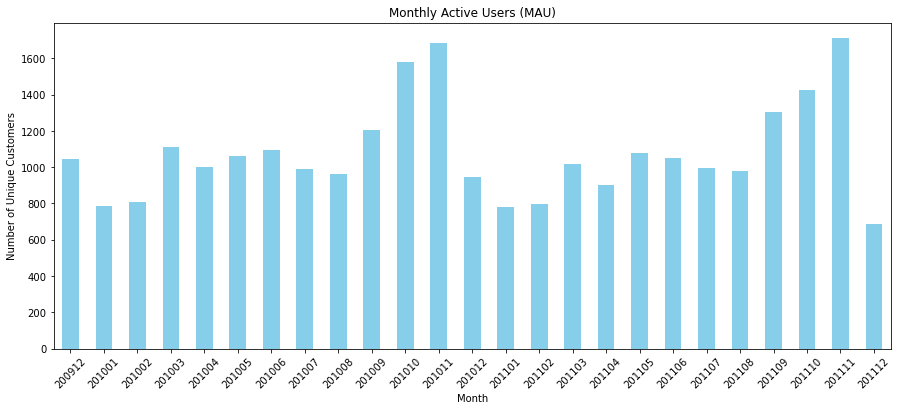

In [11]:
# Group by YYYYMM and count unique Customer IDs
monthly_active_users = retail_df.groupby('yyyymm')['customer_id'].nunique()

# Plot the bar chart
plt.figure(figsize=(15,6))
monthly_active_users.plot(kind='bar', color='skyblue')

plt.title('Monthly Active Users (MAU)')
plt.xlabel('Month')
plt.ylabel('Number of Unique Customers')
plt.xticks(rotation=45)
plt.show()

# Monthly Active Users

---
**Please remove this insturction cell after you are done with coding**

- Compute # of active users (e.g. unique `CusotomerID`) for each month
- Plot a bar chart

![](https://i.imgur.com/eFYp8VF.jpg)

---

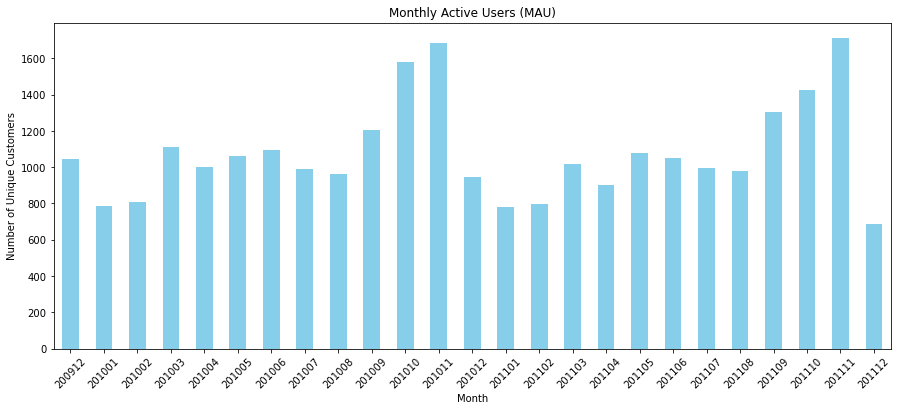

In [12]:
# Group by YYYYMM and count unique Customer IDs
monthly_active_users = retail_df.groupby('yyyymm')['customer_id'].nunique()

# Plot the bar chart
plt.figure(figsize=(15,6))
monthly_active_users.plot(kind='bar', color='skyblue')

plt.title('Monthly Active Users (MAU)')
plt.xlabel('Month')
plt.ylabel('Number of Unique Customers')
plt.xticks(rotation=45)
plt.show()

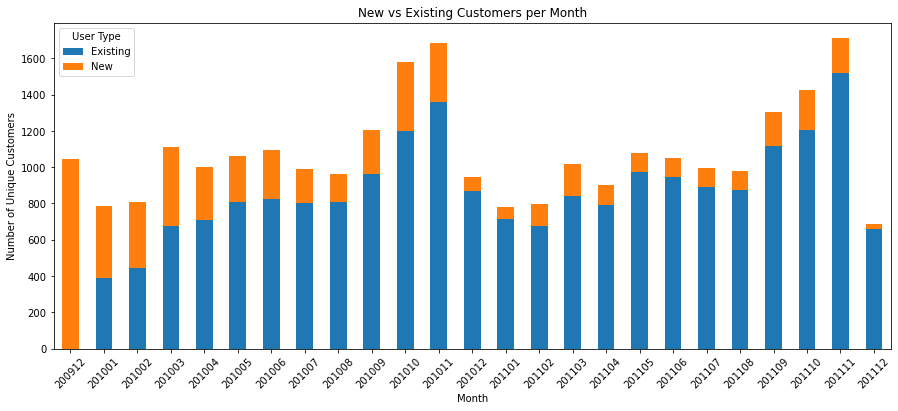

In [13]:
# 1. Find the first purchase month for each customer
first_purchase = retail_df.groupby('customer_id')['yyyymm'].min().reset_index()
first_purchase.columns = ['customer_id', 'first_month']

# 2. Merge this info back into the main DataFrame
retail_df = pd.merge(retail_df, first_purchase, on='customer_id', how='left')

# 3. Label each transaction as 'New' or 'Existing'
retail_df['user_type'] = 'Existing'
retail_df.loc[retail_df['yyyymm'] == retail_df['first_month'], 'user_type'] = 'New'

# 4. Group by Month and User Type to count unique customers
user_type_counts = retail_df.groupby(['yyyymm', 'user_type'])['customer_id'].nunique().unstack()

# 5. Plot the result
user_type_counts.plot(kind='bar', stacked=True, figsize=(15,6), color=['#1f77b4', '#ff7f0e'])
plt.title('New vs Existing Customers per Month')
plt.xlabel('Month')
plt.ylabel('Number of Unique Customers')
plt.xticks(rotation=45)
plt.legend(title='User Type')
plt.show()


# New and Existing Users



---
**Please remove this insturction cell after you are done with coding**

- Plot a diagram to show new and exiting user for each month.
- A user is identified as a new user when he/she makes the first purchase
- A user is identified as an existing user when he/she made purchases in the past
- hints:
  - find out the first purchase year-month for each user and then join this data with the transactional data to help you identified new/exiting users

![](https://i.imgur.com/nWjnrpr.jpg)

---

<Figure size 1080x432 with 0 Axes>

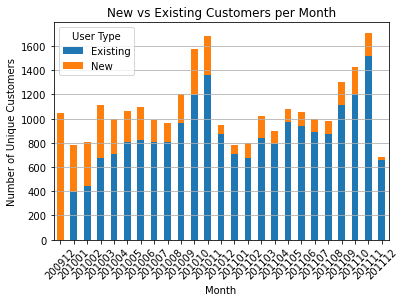

In [15]:
# 1. Reset the dataframe to ensure we don't have duplicate columns from previous runs
retail_df['invoice_date'] = pd.to_datetime(retail_df['invoice_date'])
retail_df['yyyymm'] = retail_df['invoice_date'].dt.strftime('%Y%m')

# 2. Find the first purchase month for each customer
first_purchase = retail_df.groupby('customer_id')['yyyymm'].min().reset_index()
first_purchase.columns = ['customer_id', 'first_month']

# 3. Merge this 'first_month' info back into our main DataFrame
if 'first_month' in retail_df.columns:
    retail_df = retail_df.drop(columns=['first_month'])
    
retail_df = pd.merge(retail_df, first_purchase, on='customer_id', how='left')

# 4. Create a new column 'user_type'
retail_df['user_type'] = 'Existing'

# If the transaction month equals their first month, change to 'New'
retail_df.loc[retail_df['yyyymm'] == retail_df['first_month'], 'user_type'] = 'New'

# 5. Group by Month and User Type to count unique customers
user_type_counts = retail_df.groupby(['yyyymm', 'user_type'])['customer_id'].nunique().unstack()

# 6. Plot the stacked bar chart
plt.figure(figsize=(15,6))
user_type_counts.plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'])

plt.title('New vs Existing Customers per Month')
plt.xlabel('Month')
plt.ylabel('Number of Unique Customers')
plt.xticks(rotation=45)
plt.legend(title='User Type')
plt.grid(axis='y')
plt.show()

             Recency  Frequency  Monetary
customer_id                              
12346.0          326         17    -64.68
12347.0            2          8   5633.32
12348.0           75          5   2019.40
12349.0           19          5   4404.54
12350.0          310          1    334.40


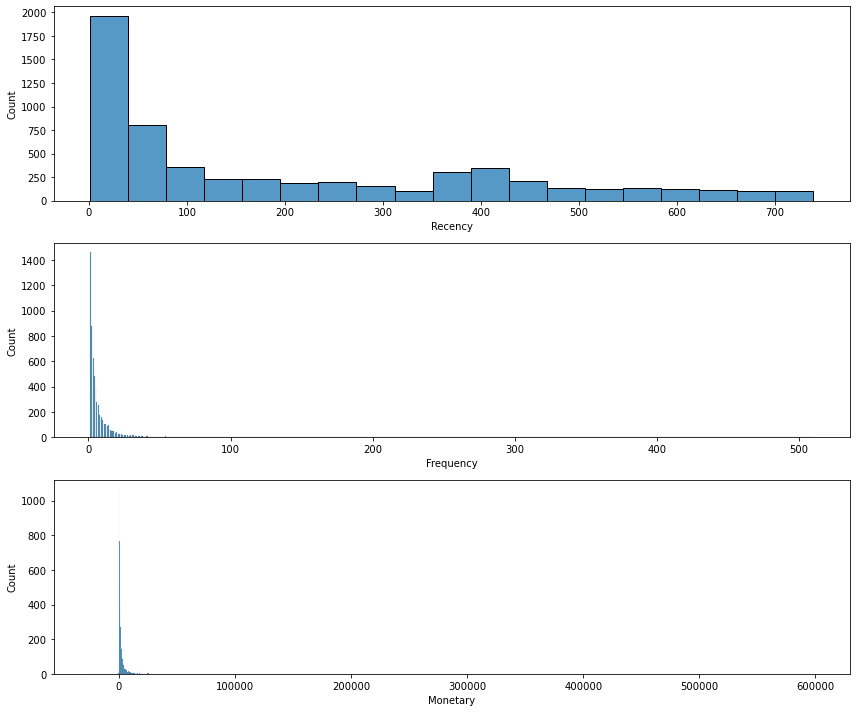

In [17]:
# 1. Import Seaborn (This is the missing line!)
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Set a reference date (The "Today" of the dataset)
last_date = retail_df['invoice_date'].max() + pd.Timedelta(days=1)

# 3. Group by Customer ID and calculate the 3 metrics
rfm = retail_df.groupby('customer_id').agg({
    'invoice_date': lambda x: (last_date - x.max()).days, 
    'invoice_no': 'nunique',                              
    'amount': 'sum'                                       
})

# 4. Rename the columns
rfm.rename(columns={
    'invoice_date': 'Recency',
    'invoice_no': 'Frequency',
    'amount': 'Monetary'
}, inplace=True)

# 5. Display the first few rows
print(rfm.head())

# 6. Plot the distributions (Now 'sns' will work)
plt.figure(figsize=(12, 10))
plt.subplot(3, 1, 1); sns.histplot(rfm['Recency'])
plt.subplot(3, 1, 2); sns.histplot(rfm['Frequency'])
plt.subplot(3, 1, 3); sns.histplot(rfm['Monetary'])
plt.tight_layout()
plt.show()

## Finding RFM

RFM is a method used for analyzing customer value. It is commonly used in database marketing and direct marketing and has received particular attention in the retail and professional services industries. ([wikipedia](https://en.wikipedia.org/wiki/RFM_(market_research)))

Optional Reading: [Making Your Database Pay Off Using Recency Frequency and Monetary Analysis](http://www.dbmarketing.com/2010/03/making-your-database-pay-off-using-recency-frequency-and-monetary-analysis/)


RFM stands for three dimensions:

- Recency – How recently did the customer purchase?

- Frequency – How often do they purchase?

- Monetary Value – How much do they spend?

Note: To simplify the problem, let's keep all placed and canceled orders.


**Sample RFM table**

![](https://i.imgur.com/sXFIg6u.jpg)

In [19]:
# 1. Set a reference date (The "Today" of the dataset)
now = retail_df['invoice_date'].max() + pd.Timedelta(days=1)

# 2. Group by Customer ID and calculate the 3 metrics
rfm = retail_df.groupby('customer_id').agg({
    'invoice_date': lambda x: (now - x.max()).days, 
    'invoice_no': 'nunique',                        
    'amount': 'sum'                               
})

# 3. Rename the columns to standard RFM names
rfm.rename(columns={
    'invoice_date': 'Recency',
    'invoice_no': 'Frequency',
    'amount': 'Monetary'
}, inplace=True)

In [20]:
rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
12346.0,326,17,-64.68
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,5,4404.54
12350.0,310,1,334.40


# RFM Segmentation

---
**Please remove this insturction cell after you are done with coding**
RFM segmentation categorizes your customers into different segments, according to their interactions with your website, which will allow you to subsequently approach these groups in the most effective way. In this article, we will show you how to make an RFM segmentation based on an RFM score combining all three RFM parameters together and allowing you to divide your customers into 11 different segments. 

- [RFM Segmentation business cases](https://docs.exponea.com/docs/rfm-segmentation-business-use)

- [RFM Segmentation Guide](https://docs.exponea.com/docs/rfm-segmentation-business-use)

As you can see, computing RFM segmentation requires extensive domain knowledge in marketing which is out of the scope in this project. In practice, you will work with BA/DA to figure out how to compute RFM segments. To simplify this project, a [sample RFM segmentation Notebook](https://github.com/jarviscanada/jarvis_data_eng_demo/blob/feature/data/python_data_wrangling/ipynb/customer-segmentation-with-rfm-score.ipynb) is provided. You are responsible to understand everything from that Notebook and then integrate it into yours. 

- Download the [sample notebook](https://github.com/jarviscanada/jarvis_data_eng_demo/blob/feature/data/python_data_wrangling/ipynb/customer-segmentation-with-rfm-score.ipynb) and import to your Jupyter Notebook or VSCode
- Run the notebook and understand all cells
- Read the remark section at the end of the notebook. You will need this information when writing the README file
- Integrate the RFM segmentation calculation into your notebook

---

In [21]:
# 1. Create labels for Recency (5 is best/most recent, 1 is worst)
r_labels = range(5, 0, -1) # [5, 4, 3, 2, 1]

# 2. Create labels for Frequency and Monetary (1 is worst, 5 is best)
f_labels = range(1, 6)     # [1, 2, 3, 4, 5]
m_labels = range(1, 6)     # [1, 2, 3, 4, 5]

# 3. Assign these labels to 5 equal percentile groups (quintiles)
r_groups = pd.qcut(rfm['Recency'], q=5, labels=r_labels)
f_groups = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=f_labels) # .rank() helps handle duplicate values
m_groups = pd.qcut(rfm['Monetary'], q=5, labels=m_labels)

# 4. Create new columns R, F, M
rfm = rfm.assign(R=r_groups.values, F=f_groups.values, M=m_groups.values)

# 5. Concatenate them into a single RFM Score string (e.g., "555")
rfm['RFM_Segment_Concat'] = rfm.apply(lambda x: str(x['R']) + str(x['F']) + str(x['M']), axis=1)

# 6. Calculate a numeric RFM Score (sum of R, F, M)
rfm['RFM_Score'] = rfm[['R', 'F', 'M']].sum(axis=1)

rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_Segment_Concat,RFM_Score
customer_id,,,,,,,,
12346.0,326,17,-64.68,2,5,1,2.05.01.0,8
12347.0,2,8,5633.32,5,4,5,5.04.05.0,14
12348.0,75,5,2019.40,3,3,4,3.03.04.0,10
12349.0,19,5,4404.54,4,3,5,4.03.05.0,12
12350.0,310,1,334.40,2,1,2,2.01.02.0,5


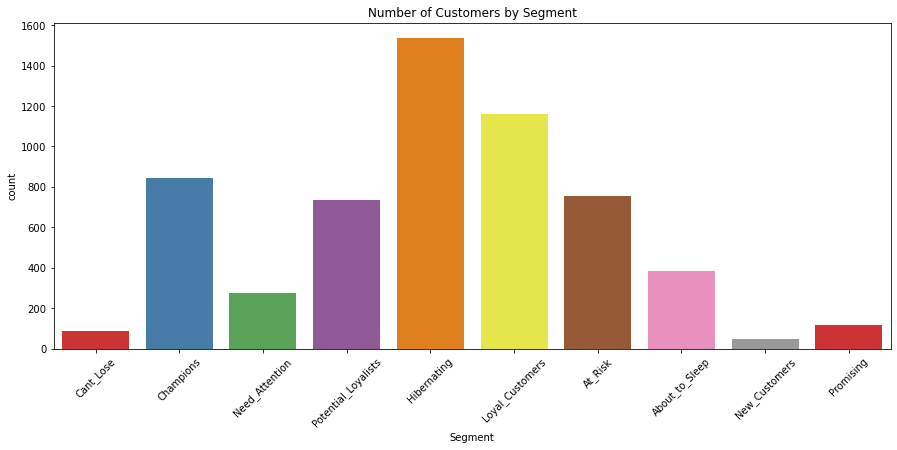

In [22]:
# Define the Segment Map
# This maps the (R)ecency and (F)requency scores to a Segment Name
segt_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At_Risk',
    r'[1-2]5': 'Cant_Lose',
    r'3[1-2]': 'About_to_Sleep',
    r'33': 'Need_Attention',
    r'[3-4][4-5]': 'Loyal_Customers',
    r'41': 'Promising',
    r'51': 'New_Customers',
    r'[4-5][2-3]': 'Potential_Loyalists',
    r'5[4-5]': 'Champions'
}

# Apply the map
rfm['Segment'] = rfm['R'].astype(str) + rfm['F'].astype(str)
rfm['Segment'] = rfm['Segment'].replace(segt_map, regex=True)

# Visualize the Segments
plt.figure(figsize=(15,6))
barplot = sns.countplot(x="Segment", data=rfm, palette="Set1")
plt.xticks(rotation=45)
plt.title("Number of Customers by Segment")
plt.show()